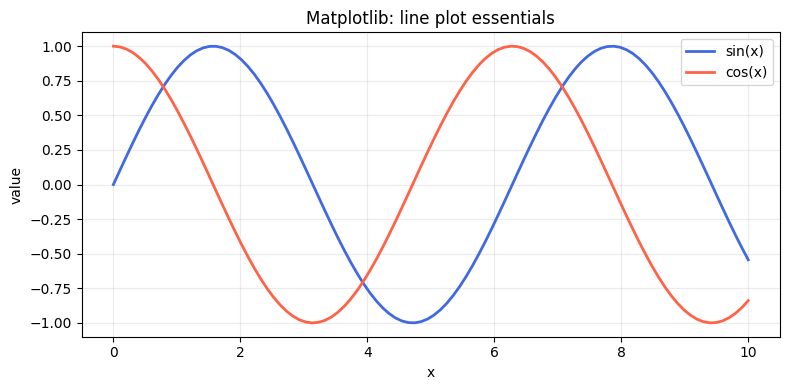

In [ ]:
# Bubble 1: Matplotlib essentials
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Matplotlib: building a multi-plot figure", fontsize=15, fontweight="bold")

# Line plot: titles, labels, legend, grid, and annotation
axes[0, 0].plot(x, y_sin, label="sin(x)", color="royalblue", linewidth=2)
axes[0, 0].plot(x, y_cos, label="cos(x)", color="red", linewidth=2)
axes[0, 0].annotate("peak", xy=(np.pi / 2, 1), xytext=(2.4, 1.2),
                    arrowprops={"arrowstyle": "->", "color": "black"})
axes[0, 0].set_title("Line plot")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("value")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

# Scatter plot: marker size and color communicate extra information
scatter_x = np.arange(1, 9)
scatter_y = np.array([3, 5, 4, 7, 6, 8, 7, 9])
axes[0, 1].scatter(scatter_x, scatter_y, s=scatter_y * 25,
                   c=scatter_y, cmap="viridis", edgecolor="black")
axes[0, 1].set_title("Scatter plot")
axes[0, 1].set_xlabel("observation")
axes[0, 1].set_ylabel("value")

# Bar chart: compare categories directly
subjects = ["Math", "Science", "English", "History"]
marks = [82, 76, 91, 68]
axes[1, 0].bar(subjects, marks, color="mediumseagreen")
axes[1, 0].set_title("Bar chart")
axes[1, 0].set_ylabel("marks")
axes[1, 0].tick_params(axis="x", rotation=20)

# Histogram: inspect the distribution of values
rng = np.random.default_rng(7)
scores = rng.normal(loc=70, scale=10, size=300) 
axes[1, 1].hist(scores, bins=15, color="darkorange", edgecolor="white")
axes[1, 1].set_title("Histogram")
axes[1, 1].set_xlabel("score")
axes[1, 1].set_ylabel("frequency")

plt.tight_layout()
plt.show()

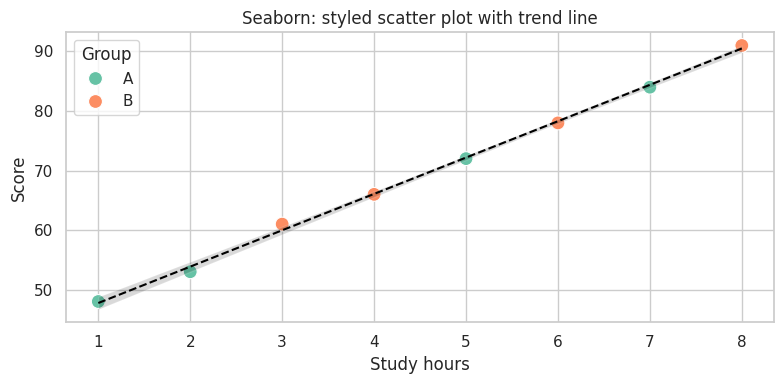

In [ ]:
# Bubble 2: Seaborn essentials
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

seaborn_data = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 2, 4, 6, 8],
    "score": [48, 53, 61, 66, 72, 78, 84, 91, 58, 70, 82, 95],
    "group": ["A", "A", "B", "B", "A", "B", "A", "B", "B", "A", "A", "B"],
    "attempt": [1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Seaborn: attractive statistical charts", fontsize=15, fontweight="bold")

# Scatterplot with semantic mappings and a trend line
sns.scatterplot(
    data=seaborn_data,
    x="study_hours",
    y="score",
    hue="group",
    style="attempt",
    size="score",
    sizes=(60, 180),
    palette="Set2",
    ax=axes[0]
)
sns.regplot(
    data=seaborn_data,
    x="study_hours",
    y="score",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--", "linewidth": 1.5},
    ax=axes[0]
)
axes[0].set_title("Scatter + trend line")
axes[0].set_xlabel("Study hours")
axes[0].set_ylabel("Score")

# Boxplot compares the score distributions for each group
sns.boxplot(data=seaborn_data, x="group", y="score", hue="group",
            palette="Set2", legend=False, ax=axes[1])
sns.stripplot(data=seaborn_data, x="group", y="score", color="black",
              alpha=0.55, jitter=True, ax=axes[1])
axes[1].set_title("Distribution by group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Score")

# Heatmap makes a small table easier to compare at a glance
score_table = seaborn_data.pivot_table(
    index="group", columns="attempt", values="score", aggfunc="mean"
)
sns.heatmap(score_table, annot=True, fmt=".1f", cmap="YlGnBu",
            linewidths=1, cbar_kws={"label": "average score"}, ax=axes[2])
axes[2].set_title("Average score heatmap")
axes[2].set_xlabel("Attempt")
axes[2].set_ylabel("Group")

plt.tight_layout()
plt.show()